In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("data-export (1).csv")

In [8]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [9]:
# The Given Data Contains unnamed columns 

In [10]:
df.columns = df.iloc[0]

In [13]:
df.head()
df = df.drop(index=0).reset_index(drop = True)

In [15]:
df.columns = ["Channel group","Datehour","Users","Sessions"," Engaged sessions","Average Engagement time per session"," Engaged sessions per user","Events per session","Engagement rate","Event count"]

In [16]:
df.head()

,Channel group,Datehour,Users,Sessions,Engaged sessions,Average Engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Channel group                        3182 non-null   object
 1   Datehour                             3182 non-null   object
 2   Users                                3182 non-null   object
 3   Sessions                             3182 non-null   object
 4    Engaged sessions                    3182 non-null   object
 5   Average Engagement time per session  3182 non-null   object
 6    Engaged sessions per user           3182 non-null   object
 7   Events per session                   3182 non-null   object
 8   Engagement rate                      3182 non-null   object
 9   Event count                          3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


In [18]:
df.size

31820

In [21]:
# convert DateHOurs from object to Date Format

In [23]:
df['Datehour'] = pd.to_datetime(df['Datehour'],format="%Y%m%d%H",errors='coerce')

In [24]:
# converting the necessary columns to numeric

In [27]:
numeric_columns = df.columns.drop(['Channel group','Datehour'])
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric,errors='coerce')
df['Hour'] = df['Datehour'].dt.hour

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Channel group                        3182 non-null   object        
 1   Datehour                             3182 non-null   datetime64[ns]
 2   Users                                3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4    Engaged sessions                    3182 non-null   int64         
 5   Average Engagement time per session  3182 non-null   float64       
 6    Engaged sessions per user           3182 non-null   float64       
 7   Events per session                   3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event count                          3182 non-null   int64         
 10  Hour        

In [30]:
df.describe()

,Datehour,Users,Sessions,Engaged sessions,Average Engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


# Sessions and Users overTime 

In [31]:
sns.set(style="whitegrid")

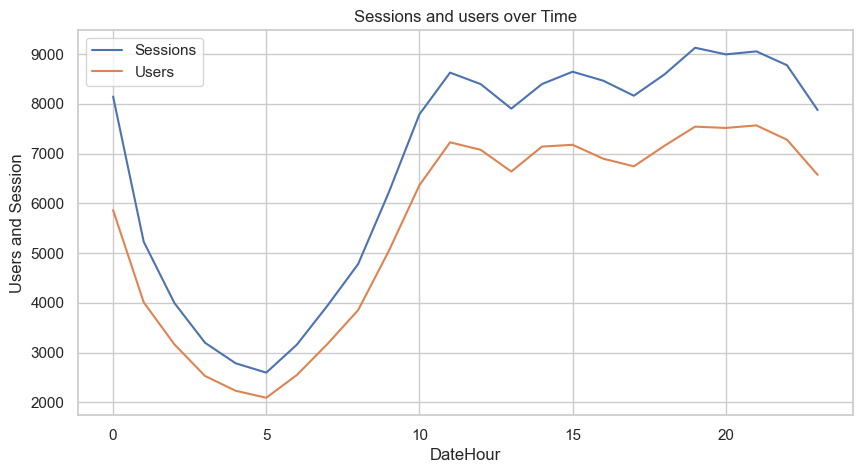

In [35]:
plt.figure(figsize=(10,5))
df.groupby('Hour')[['Sessions','Users']].sum().plot(ax=plt.gca())
plt.title("Sessions and users over Time")
plt.xlabel("DateHour")
plt.ylabel("Users and Session")
plt.show()

# Total Users by Channel

C:\Users\AROMAL\AppData\Local\Temp\ipykernel_9304\381141329.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='Channel group',y='Users',estimator=np.sum,palette='viridis')


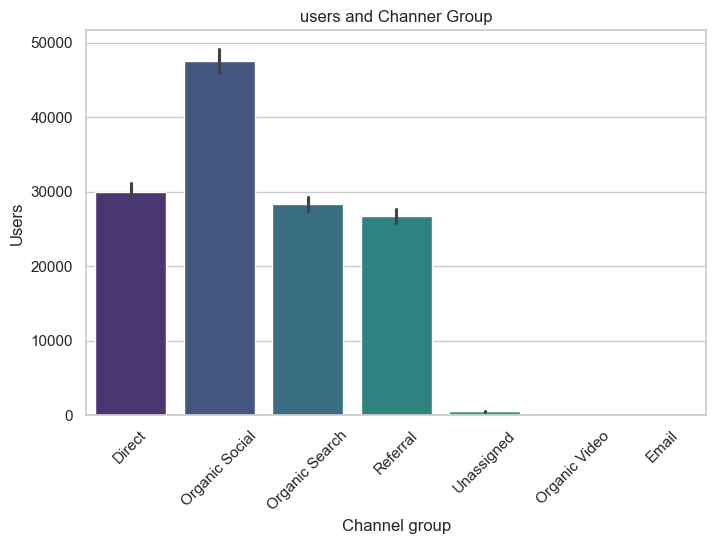

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='Channel group',y='Users',estimator=np.sum,palette='viridis')
plt.title("users and Channer Group")
plt.xticks(rotation=45)
plt.show()

In [38]:
df.head()

,Channel group,Datehour,Users,Sessions,Engaged sessions,Average Engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


# Average Engagement Time By Channel

C:\Users\AROMAL\AppData\Local\Temp\ipykernel_9304\468871479.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='Channel group',y='Average Engagement time per session',estimator=np.mean,palette="magma")


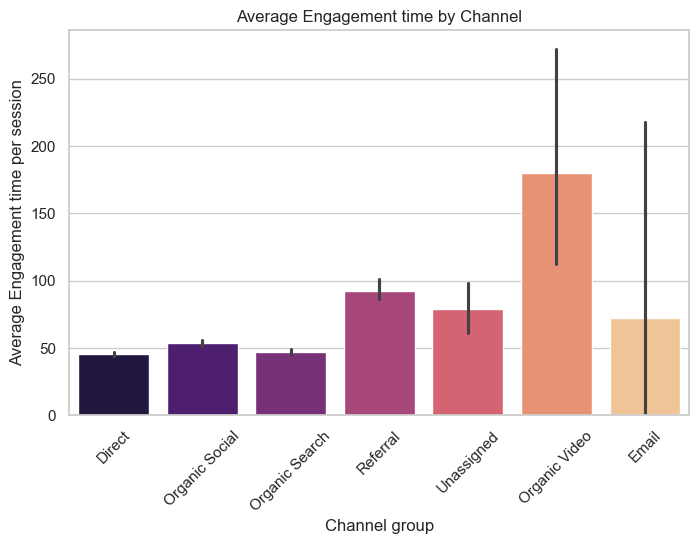

In [41]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='Channel group',y='Average Engagement time per session',estimator=np.mean,palette="magma")
plt.title("Average Engagement time by Channel")
plt.xticks(rotation=45)
plt.show()

# Engagement Rate Distribution By Channel

C:\Users\AROMAL\AppData\Local\Temp\ipykernel_9304\3471148306.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Channel group' , y='Engagement rate',palette='magma')


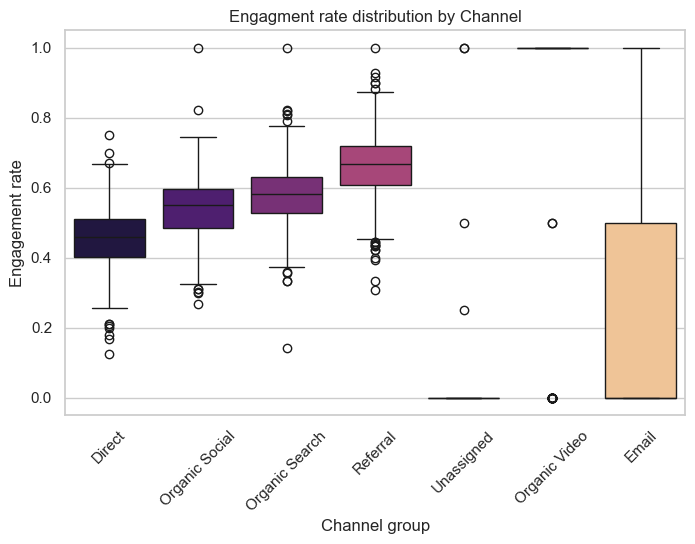

In [44]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='Channel group' , y='Engagement rate',palette='magma')
plt.title("Engagment rate distribution by Channel")
plt.xticks(rotation=45)
plt.show()

# Engaged VS Non Engaged Sessions 

In [66]:
session_df = df.groupby('Channel group')[["Sessions","Engaged sessions"]].sum().reset_index()

In [51]:
df.head()

,Channel group,Datehour,Users,Sessions,Engaged sessions,Average Engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [67]:
session_df = df.groupby('Channel group')[['Sessions','Engaged sessions']].sum()

In [53]:
df.columns = df.columns.str.strip() 

In [62]:
session_df = df.groupby('Channel group')[['Sessions','Engaged sessions']].sum().reset_index()

In [63]:
session_df['Non-engaged'] = session_df['Sessions'] - session_df['Engaged sessions']

In [64]:
df.head()

,Channel group,Datehour,Users,Sessions,Engaged sessions,Average Engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [65]:
session_df_melted = session_df.melt(id_vars="Channel group",value_vars=['Engaged sessions','Non-engaged'])

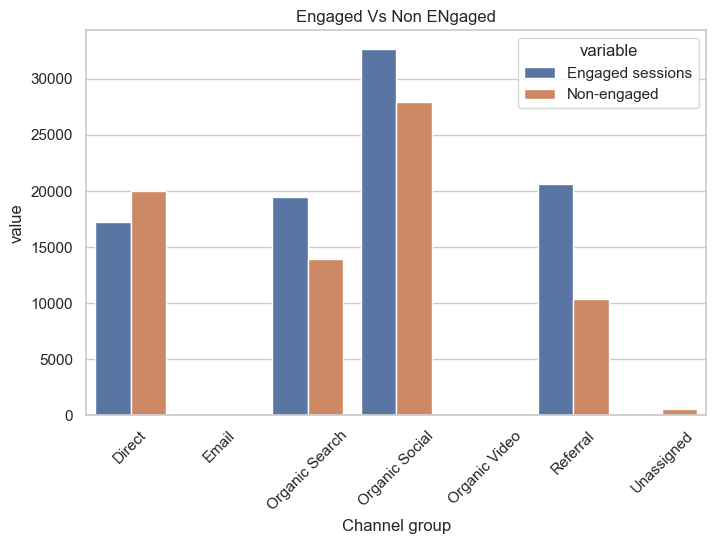

In [70]:
plt.figure(figsize=(8,5))
sns.barplot(data=session_df_melted,x='Channel group',y='value',hue='variable')
plt.title("Engaged Vs Non ENgaged")
plt.xticks(rotation=45)
plt.show()

# Traffic by Hour and Channel

In [71]:
heatmap_data = df.groupby(['Hour','Channel group'])['Sessions'].sum().unstack().fillna(0)

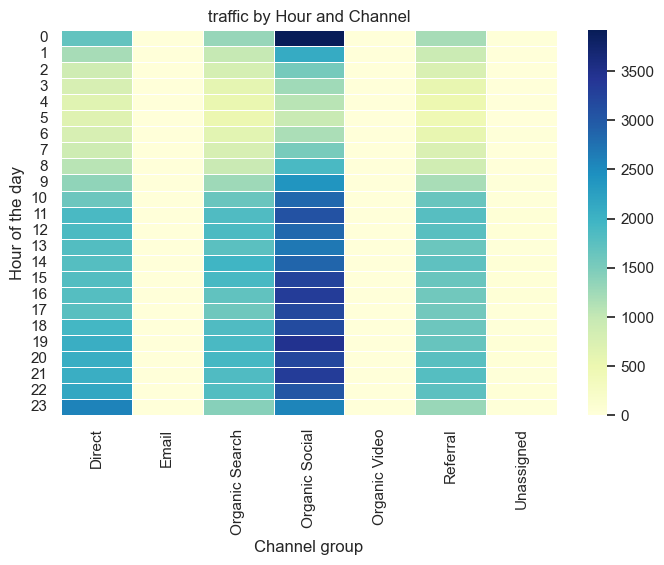

In [75]:
plt.figure(figsize=(8,5))
sns.heatmap(heatmap_data, cmap='YlGnBu',linewidths=.5, fmt='0.0f')
plt.title('traffic by Hour and Channel')
plt.xlabel('Channel group')
plt.ylabel('Hour of the day')
plt.show()